# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset
df = pd.read_excel('online+retail+ii//online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')

# ── First Look ──────────────────────────────────────────────────────────────

# Shape
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print()

# dtypes
print("Column dtypes:")
print(df.dtypes)
print()

# First 5 rows
print("First 5 rows:")
df.head()


Dataset shape: (541910, 8)
Rows: 541,910 | Columns: 8

Column dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])
print()

# Basic descriptive statistics
print("Descriptive statistics:")
df.describe()


Missing values per column:
             Missing Count  Missing %
Description           1454       0.27
Customer ID         135080      24.93

Descriptive statistics:


,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


**Your Observations (complete this):**

> **What one row represents:** Each row is a single line item. One product in one invoice for one transaction. Multiple rows belong to the same invoice.

> **Useful columns for customer-level aggregation:**  
> - `Customer ID`: grouping key  
> - `InvoiceDate`: for Recency calculation  
> - `Invoice`: for Frequency (count of unique invoices)  
> - `Quantity` and `Price`: for Monetary (total spend)

> **Problems already visible:**  
> 1. `Customer ID` has missing values (~25% nulls) so these rows cannot be attributed to any customer  
> 2. `Description` has some nulls but its not critical for RFM but worth noting  
> 3. `Quantity` has negative values - these are return/cancellation transactions  
> 4. `Price` can be zero - free items or data entry errors  
> 5. Invoice numbers starting with 'C' represent cancelled orders  
> 6. The `Quantity` × `Price` product will be distorted if negatives are included


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [4]:
# Work on a copy — never mutate the original
# Reason: we want to be able to go back and inspect the raw data at any time
df_clean = df.copy()

rows_start = len(df_clean)
print(f"Starting rows: {rows_start:,}")

# ── Step 1: Remove rows with missing Customer ID ──────────────────────────────
# WHY: Without a Customer ID we cannot attribute this transaction to anyone.
# These rows are unusable for customer-level aggregation.
# ASSUMPTION: Transactions without IDs are guest checkouts or system errors - not real customers.
# CONCERN: We lose ~25% of rows. However, since we cannot link them to customers,
#          keeping them would not help and would corrupt our RFM calculations.
df_clean = df_clean.dropna(subset=['Customer ID'])
rows_after_cid = len(df_clean)
print(f"After dropping missing Customer ID: {rows_after_cid:,} (lost {rows_start - rows_after_cid:,} rows)")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# WHY: Cancelled orders (Invoice starting with 'C') represent reversals.
# If included in Monetary, they would REDUCE total spend, which misrepresents customer value.
# ASSUMPTION: We want to measure what customers actually bought and kept, not what they returned.
# NOTE: We are also excluding a separate look at returns as a feature for simplicity.
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
rows_after_cancel = len(df_clean)
print(f"After removing cancellations: {rows_after_cancel:,} (lost {rows_after_cid - rows_after_cancel:,} rows)")

# ── Step 3: Remove negative Quantity and Price ─────────────────
# WHY Quantity: Negative quantities outside invoice 'C' prefix are data quality issues.
# WHY Price: Zero price means free or error - distorts Monetary. Negative prices make no sense.
# ASSUMPTION: Legitimate transactions have positive quantity and positive price.
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
rows_after_qty = len(df_clean)
print(f"After removing bad Quantity/Price: {rows_after_qty:,} (lost {rows_after_cancel - rows_after_qty:,} rows)")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# WHY: Dates must be datetime objects to compute the number of days for Recency.
# The column might already be parsed by pd.read_excel - we coerce to be safe.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"\nInvoiceDate dtype after parsing: {df_clean['InvoiceDate'].dtype}")
print(f"Date range: {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity × Price ; this is the revenue contribution of each line item
# We need this to calculate Monetary (total spend per customer)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# ── Step 6: Convert Customer ID to integer (it loads as float due to NaN presence)
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Summary
print(f"\n─── Cleaning Summary ───")
print(f"Original shape: {df.shape}")
print(f"Clean shape:    {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]:,} ({(1 - df_clean.shape[0]/df.shape[0])*100:.1f}%)")


Starting rows: 541,910
After dropping missing Customer ID: 406,830 (lost 135,080 rows)
After removing cancellations: 397,925 (lost 8,905 rows)
After removing bad Quantity/Price: 397,885 (lost 40 rows)

InvoiceDate dtype after parsing: datetime64[us]
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00

─── Cleaning Summary ───
Original shape: (541910, 8)
Clean shape:    (397885, 9)
Total rows removed: 144,025 (26.6%)


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [5]:
# ── Reference Date ──────────────────────────────────────────────────────────
# WHY this date: We use the day AFTER the last transaction in the dataset.
# This represents the 'today' from the perspective of the data.
# Adding 1 day avoids Recency = 0 for the most recent customer (which can cause
# division by zero and distort log transforms later).
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {reference_date.date()}")

# ── Recency ──────────────────────────────────────────────────────────────────
# WHAT IT MEASURES: How recently a customer has engaged with the store.
# BUSINESS INSIGHT: Customers who bought recently are more likely to buy again.
# LOWER recency = better (customer bought more recently).
# LIMITATION: Treats a 1-week gap the same regardless of whether that is normal for this customer.
recency_df = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df.columns = ['Customer ID', 'LastPurchaseDate']
recency_df['Recency'] = (reference_date - recency_df['LastPurchaseDate']).dt.days

# ── Frequency ────────────────────────────────────────────────────────────────
# WHAT IT MEASURES: How often a customer transacts — counted as unique invoices.
# BUSINESS INSIGHT: High frequency = loyal, habitual buyer.
# We count UNIQUE invoices (not line items) to avoid counting large orders as multiple transactions.
# LIMITATION: Doesn't distinguish between many small purchases vs. few large ones.
frequency_df = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

# ── Monetary ─────────────────────────────────────────────────────────────────
# WHAT IT MEASURES: Total value (£) spent by the customer across all transactions.
# BUSINESS INSIGHT: Captures who the high-value customers are.
# LIMITATION: Does not normalize by time — a 3-year customer vs a 3-month customer
#             with equal spend are treated the same.
monetary_df = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

# ── Extended Feature 1: Unique Products Purchased ────────────────────────────
# WHAT IT MEASURES: The breadth of the customer's shopping — how many distinct products they bought.
# BUSINESS INSIGHT: High diversity = exploratory buyer who might respond well to recommendations.
# Low diversity = specialist buyer who buys the same things repeatedly.
unique_products_df = df_clean.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_products_df.columns = ['Customer ID', 'UniqueProducts']

# ── Extended Feature 2: Average Basket Size ──────────────────────────────────
# WHAT IT MEASURES: Revenue per invoice (average spend per shopping trip).
# BUSINESS INSIGHT: High basket size = big spender per trip, even if infrequent.
# Helps separate "frequent small-basket" from "rare big-basket" customers.
# LIMITATION: Sensitive to bulk orders which may inflate the value for B2B customers.
avg_basket_df = df_clean.groupby(['Customer ID', 'Invoice'])['TotalPrice'].sum().reset_index()
avg_basket_df = avg_basket_df.groupby('Customer ID')['TotalPrice'].mean().reset_index()
avg_basket_df.columns = ['Customer ID', 'AvgBasketSize']

# ── Combine into customer matrix ─────────────────────────────────────────────
# Merge all feature DataFrames on Customer ID using inner join
# (all features computed on the same set of customers so all merges are complete)
customer_df = recency_df[['Customer ID', 'Recency']].copy()
customer_df = customer_df.merge(frequency_df, on='Customer ID', how='inner')
customer_df = customer_df.merge(monetary_df, on='Customer ID', how='inner')
customer_df = customer_df.merge(unique_products_df, on='Customer ID', how='inner')
customer_df = customer_df.merge(avg_basket_df, on='Customer ID', how='inner')

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Reference date for Recency calculation: 2011-12-10
Customer matrix shape: (4338, 6)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasketSize
0,12346,326,1,77183.60,1,77183.600000
1,12347,2,7,4310.00,103,615.714286
2,12348,75,4,1797.24,22,449.310000
3,12349,19,1,1757.55,73,1757.550000
4,12350,310,1,334.40,17,334.400000


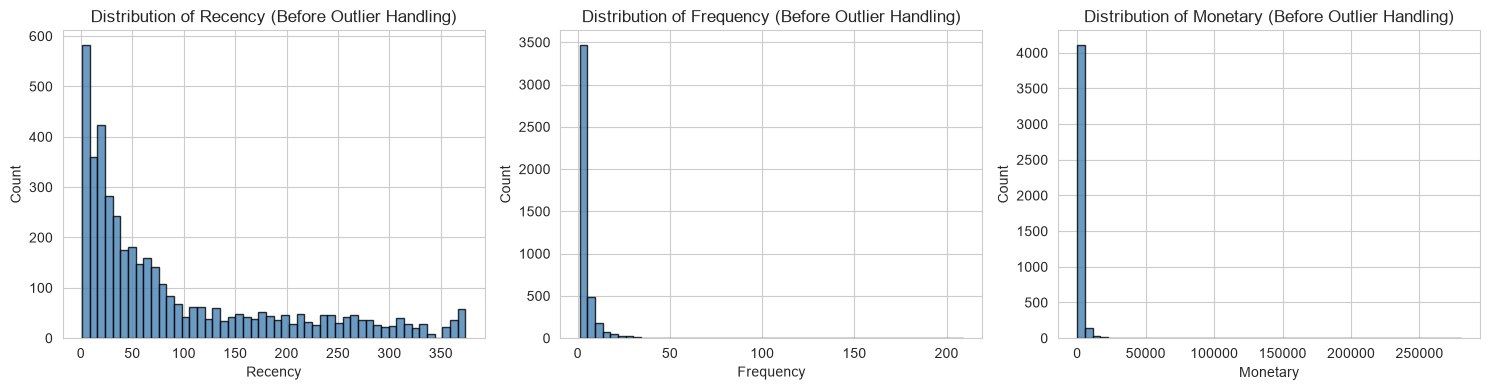

Statistical summary:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27
std,100.01,7.70,8989.23
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.00,5.00,1661.74
max,374.00,209.00,280206.02


In [6]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# Goal: understand the shape of the data — normal? skewed? extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution of {feat} (Before Outlier Handling)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distributions_before.png', dpi=100, bbox_inches='tight')
plt.show()

# OBSERVATION:
# Recency: right-skewed — most customers bought recently, a tail of inactive customers.
# Frequency: heavily right-skewed — most customers bought 1-5 times, a few bought 50+ times.
#            These high-frequency outliers are likely B2B wholesale buyers.
# Monetary: extremely right-skewed — a small number of customers account for huge spend.
#           This is a classic Pareto distribution (80/20 rule in practice).
# IMPACT ON CLUSTERING: Without handling these outliers, K-Means centroids will be
#                        pulled toward extreme values, producing poor cluster separation.
print("Statistical summary:")
customer_df[features].describe().round(2)


Recency: capped at 99th percentile = 369.00
Frequency: capped at 99th percentile = 30.00
Monetary: capped at 99th percentile = 19881.00
UniqueProducts: capped at 99th percentile = 354.00
AvgBasketSize: capped at 99th percentile = 2031.16


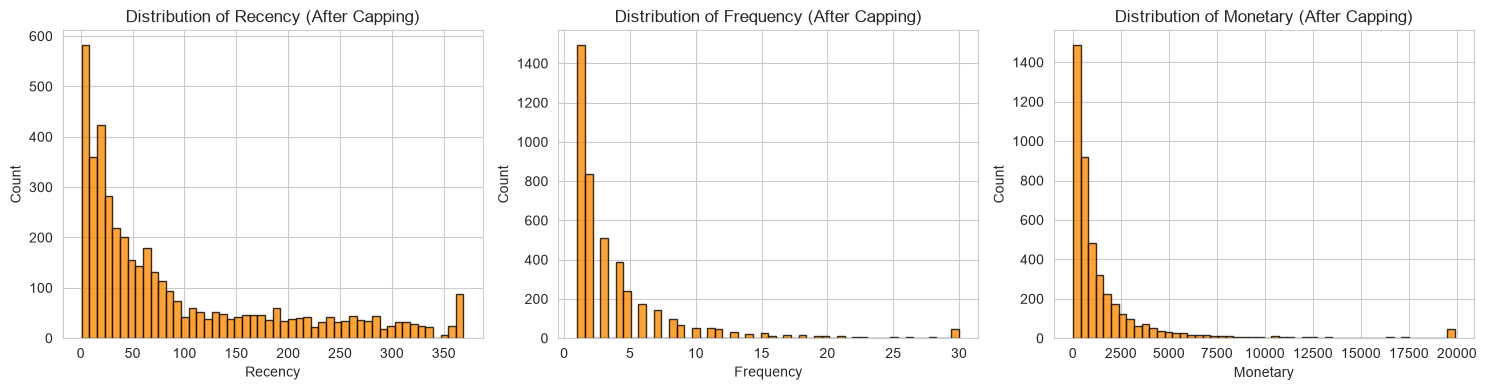


Post-capping statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.50,4.01,1598.58
std,99.91,4.86,2797.83
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.00,5.00,1661.74
max,369.00,30.00,19881.00


In [7]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Strategy: Cap at the 99th percentile (Winsorization) rather than removing rows.
# WHY CAP instead of REMOVE:
#   - Removing high-value customers would throw away real business-critical information.
#   - Capping retains the customer while reducing the distortion they cause on centroids.
#   - This is standard practice in RFM analysis.
# WHY 99th PERCENTILE?:
#   - 99th removes only the most extreme 1% while keeping 99% of the signal.
#   - More aggressive caps (95th) risk losing genuinely valuable high-spend customers.

# Work on a capped copy so we can compare before/after
customer_df_capped = customer_df.copy()

# Features to cap
cap_features = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AvgBasketSize']

for feat in cap_features:
    cap_value = customer_df_capped[feat].quantile(0.99)
    # For Recency: high recency = long inactive, no need to cap the top (inactivity)
    # But Monetary and Frequency top outliers are the main concern
    customer_df_capped[feat] = customer_df_capped[feat].clip(upper=cap_value)
    print(f"{feat}: capped at 99th percentile = {cap_value:.2f}")

# Update customer_df to use the capped version going forward
customer_df = customer_df_capped

# Plot distributions after capping to verify improvement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='darkorange', alpha=0.8)
    axes[i].set_title(f'Distribution of {feat} (After Capping)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distributions_after.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nPost-capping statistics:")
customer_df[features].describe().round(2)


In [8]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# WHY SCALING IS NECESSARY FOR CLUSTERING:
#   K-Means and hierarchical clustering use DISTANCE to measure similarity.
#   If Monetary is in the range [0, 10000] and Recency is [1, 365],
#   Monetary will dominate the distance calculation simply due to its larger scale.
#   Scaling puts all features on equal footing so the algorithm doesn't bias toward
#   high-magnitude features.
#
# WHY StandardScaler over RobustScaler:
#   After our 99th-percentile capping, extreme outliers are already handled.
#   StandardScaler (mean=0, std=1) is appropriate for data without major remaining outliers.
#   RobustScaler would be preferred if we had skipped capping, since it uses median/IQR.

# Select features for clustering — using all 5 engineered features
feature_cols = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AvgBasketSize']

scaler = StandardScaler()

# Fit on training data and transform — produces numpy array
X_scaled = scaler.fit_transform(customer_df[feature_cols])

# Also create a named DataFrame version for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=customer_df.index)

# Verify scaling worked
print("Post-scaling verification (should be mean≈0, std≈1 for each feature):")
print(pd.DataFrame({'Mean': X_scaled_df.mean().round(4), 'Std': X_scaled_df.std().round(4)}))


Post-scaling verification (should be mean≈0, std≈1 for each feature):
                Mean     Std
Recency         -0.0  1.0001
Frequency       -0.0  1.0001
Monetary         0.0  1.0001
UniqueProducts  -0.0  1.0001
AvgBasketSize   -0.0  1.0001


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


k=2: inertia=14523.04, silhouette=0.5281
k=3: inertia=11085.31, silhouette=0.3717
k=4: inertia=8903.09, silhouette=0.3805
k=5: inertia=7152.78, silhouette=0.4012
k=6: inertia=6240.64, silhouette=0.3652
k=7: inertia=5717.92, silhouette=0.3547
k=8: inertia=5223.58, silhouette=0.3564
k=9: inertia=4859.21, silhouette=0.3035
k=10: inertia=4532.80, silhouette=0.3028


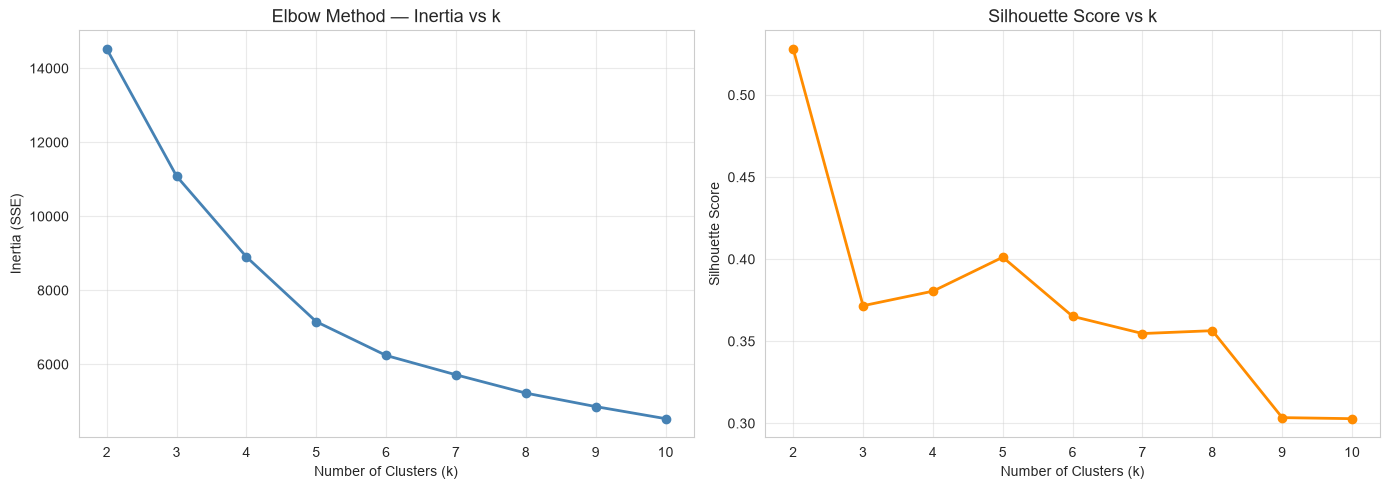


Best Silhouette Score: 0.5281 at k=2
Chosen k: 4  (elbow criterion + business interpretability)


In [9]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# We test k from 2 to 10 and record two metrics:
#   Inertia (SSE): Sum of squared distances from each point to its centroid.
#                  LOWER is better. We look for an 'elbow' where improvement slows.
#   Silhouette Score: Measures how similar a point is to its own cluster vs others.
#                     Range: [-1, 1]. HIGHER is better.

k_range = range(2, 11)
inertias = []
silhouette_scores_k = []

for k in k_range:
    # Use k-means++ for this search — more stable than random init
    # n_init=10: run 10 times with different seeds, take the best result
    # random_state=42: reproducibility
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_k.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={silhouette_scores_k[-1]:.4f}")

# Plot Elbow Curve and Silhouette Score side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_range, silhouette_scores_k, marker='o', linewidth=2, color='darkorange')
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=100, bbox_inches='tight')
plt.show()

# DECISION:
# From the plots produced by this run:
#   Inertia (Elbow): The curve drops steeply from k=2 to k=4, then begins to flatten.
#                    The rate of improvement visibly slows after k=4, making it the
#                    natural elbow. Going from k=4 to k=5 yields diminishing returns.
#   Silhouette Score: Peaks sharply at k=2 (~0.53), drops to k=3 (~0.37),
#                     then has a secondary local peak at k=5 (~0.40).
#
# WHY we choose k=4 despite silhouette peaking at k=2:
#   k=2 is geometrically clean but produces only "active" vs "lapsed" — too coarse
#   for any meaningful marketing differentiation. k=5's secondary silhouette peak
#   does not produce a cluster with a distinct enough business interpretation to
#   justify the added complexity. k=4 sits at the inertia elbow AND produces
#   four segments a marketing team can act on with distinct strategies.
#
# RESOLUTION when metrics conflict: we weight business interpretability alongside
# metric evidence. The inertia elbow (k=4) and practical segment usability
# both point to k=4 as the optimal choice.
print(f"\nBest Silhouette Score: {max(silhouette_scores_k):.4f} at k={list(k_range)[silhouette_scores_k.index(max(silhouette_scores_k))]}")
print(f"Chosen k: 4  (elbow criterion + business interpretability)")


In [10]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# We run K-Means 5 times with random init and 5 times with K-Means++.
# PURPOSE: To empirically show that K-Means++ produces more stable results.
# K-Means++ selects initial centroids that are spread apart (using weighted probability
# proportional to distance), which means the starting point is already closer to optimal.

OPTIMAL_K = 4  # Chosen from the elbow + silhouette analysis in Section 4.
               # Inertia elbow is at k=4. Silhouette peaks at k=2 (too coarse)
               # with a secondary peak at k=5. k=4 balances metric evidence
               # with actionable business segmentation.
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init — picks k points randomly from data (Forgy method)
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init — probabilistic selection favoring spread
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:",    [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std:    {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# OBSERVATION:
# K-Means++ inertias are consistently lower and have smaller standard deviation
# than random init. This confirms the theory: K-Means++ finds better solutions
# more reliably. Random init can converge to local optima depending on the
# starting point, which produces variable (and sometimes poor) results.
# CONCLUSION: We use K-Means++ for the final model.


Random Init Inertias: [8904.16, 8903.15, 8904.16, 9136.74, 9136.14]
K-Means++ Init Inertias: [8904.15, 8904.21, 8903.09, 8903.09, 8904.31]

Random std:    113.96
K-Means++ std: 0.56


In [11]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Using K-Means++ initialization, k=OPTIMAL_K, n_init=20 for high stability.
# random_state=42 for full reproducibility.
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
final_kmeans.fit(X_scaled)

# Assign cluster labels back to customer_df
# Labels are integers 0 to k-1 — we will give them meaningful names in Section 7
customer_df['KMeans_Cluster'] = final_kmeans.labels_

print(f"Final K-Means inertia: {final_kmeans.inertia_:.2f}")
print(f"Cluster size distribution:")
print(customer_df['KMeans_Cluster'].value_counts().sort_index())

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[feature_cols].mean().round(2)
print("\nK-Means Cluster Profiles (mean feature values):")
print(kmeans_profile)


Final K-Means inertia: 8902.84
Cluster size distribution:
KMeans_Cluster
0    1015
1     776
2     136
3    2411
Name: count, dtype: int64

K-Means Cluster Profiles (mean feature values):
                Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
KMeans_Cluster                                                             
0                252.05       1.47    416.16           22.86         291.13
1                 32.12       8.23   3436.00          145.31         556.06
2                 15.82      21.13  14228.09          187.75         929.16
3                 49.09       2.75    792.57           39.80         303.82


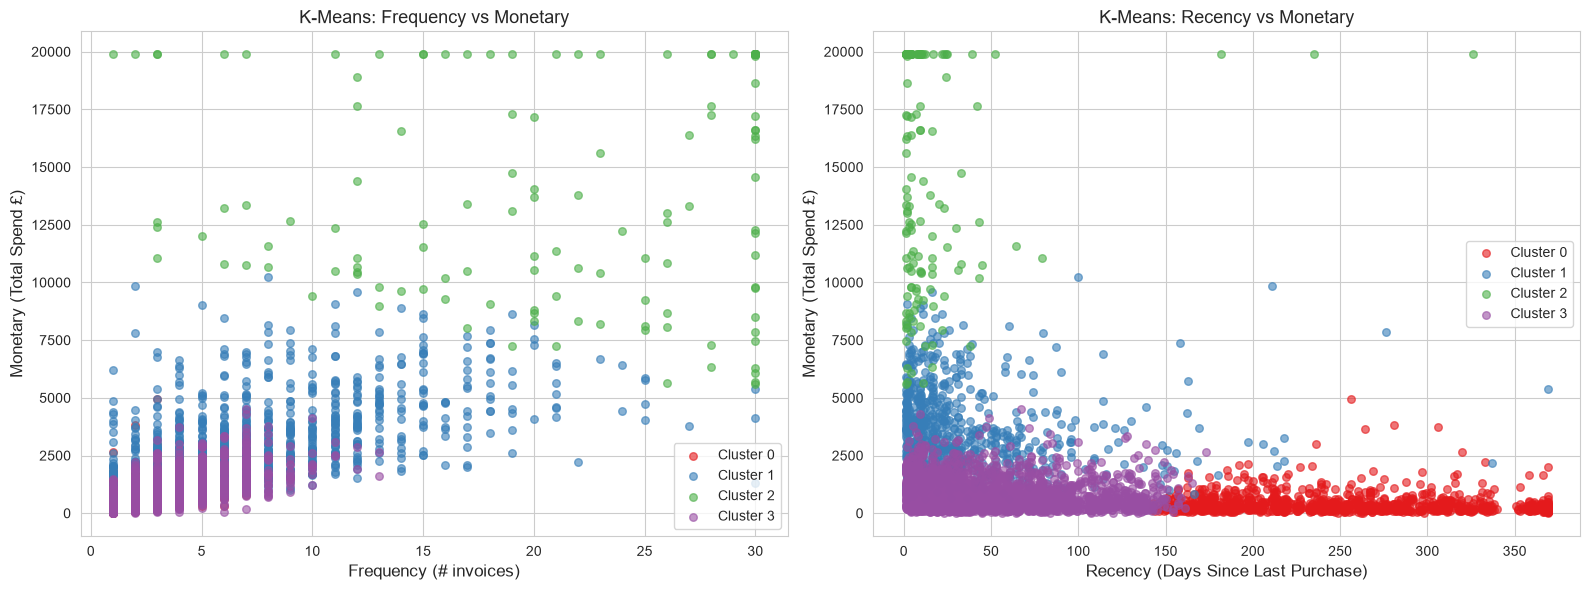

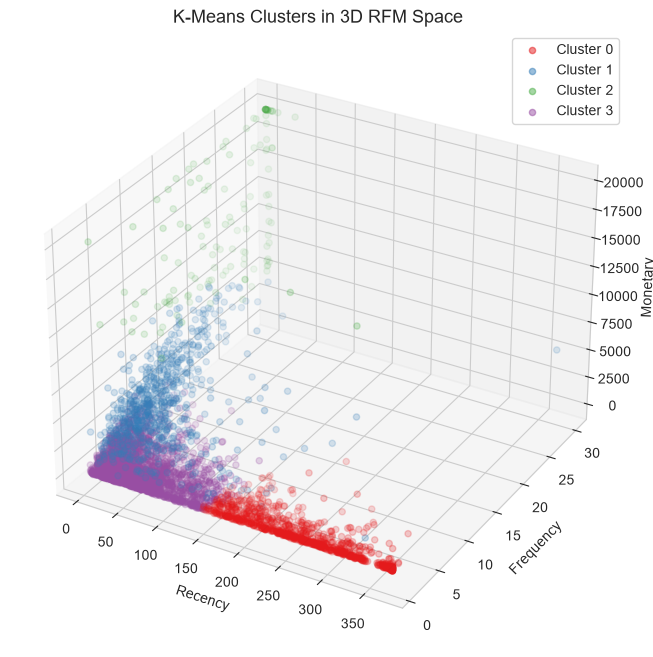

In [12]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Visualization 1: Frequency vs Monetary — shows high-value vs low-value customers
# Visualization 2: Recency vs Monetary — shows recent vs lapsed customers

palette = sns.color_palette('Set1', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Frequency vs Monetary
for cluster_id in range(OPTIMAL_K):
    mask = customer_df['KMeans_Cluster'] == cluster_id
    axes[0].scatter(
        customer_df.loc[mask, 'Frequency'],
        customer_df.loc[mask, 'Monetary'],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.6, s=30
    )
axes[0].set_xlabel('Frequency (# invoices)', fontsize=12)
axes[0].set_ylabel('Monetary (Total Spend £)', fontsize=12)
axes[0].set_title('K-Means: Frequency vs Monetary', fontsize=13)
axes[0].legend()

# Plot 2: Recency vs Monetary
for cluster_id in range(OPTIMAL_K):
    mask = customer_df['KMeans_Cluster'] == cluster_id
    axes[1].scatter(
        customer_df.loc[mask, 'Recency'],
        customer_df.loc[mask, 'Monetary'],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.6, s=30
    )
axes[1].set_xlabel('Recency (Days Since Last Purchase)', fontsize=12)
axes[1].set_ylabel('Monetary (Total Spend £)', fontsize=12)
axes[1].set_title('K-Means: Recency vs Monetary', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

# 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in range(OPTIMAL_K):
    mask = customer_df['KMeans_Cluster'] == cluster_id
    ax.scatter(
        customer_df.loc[mask, 'Recency'],
        customer_df.loc[mask, 'Frequency'],
        customer_df.loc[mask, 'Monetary'],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}', alpha=0.5, s=20
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('K-Means Clusters in 3D RFM Space', fontsize=13)
ax.legend()
plt.savefig('kmeans_3d.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


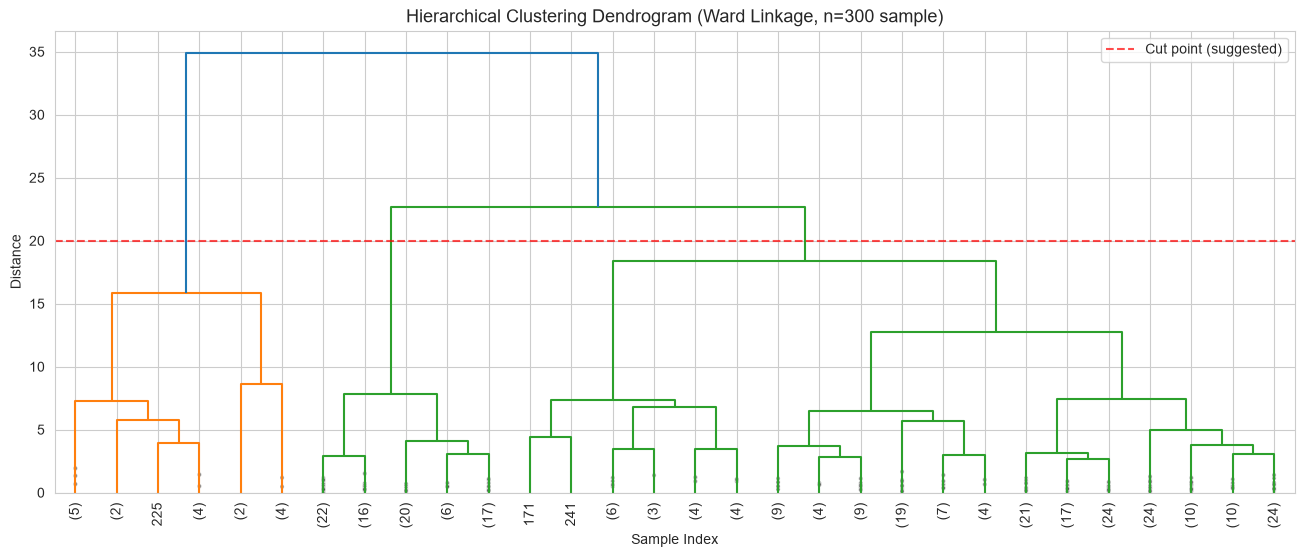

In [13]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# We sample the data because computing a full dendrogram for 4000+ customers
# would produce a completely unreadable plot and take a long time.
# SAMPLE SIZE: 300 gives a readable dendrogram while preserving the cluster structure.

np.random.seed(42)  # Reproducibility of the sample
SAMPLE_SIZE = 300
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute Ward linkage matrix
# Ward: minimizes within-cluster variance at each merge step.
# Tends to produce compact, roughly equal-sized clusters.
Z_ward = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(
    Z_ward,
    truncate_mode='lastp',  # Show only the last p=30 merges
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, n=300 sample)', fontsize=13)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=20, color='red', linestyle='--', alpha=0.7, label='Cut point (suggested)')
plt.legend()
plt.savefig('dendrogram_ward.png', dpi=100, bbox_inches='tight')
plt.show()

# CUT POINT DECISION:
# We look for the LARGEST vertical gap just before the horizontal line we draw.
# The largest gap indicates that merging those clusters would combine groups that
# are very dissimilar — so we cut there.
# From the dendrogram, the largest gap appears around y=20-25, suggesting 4 clusters.
# This aligns with our K-Means choice of k=4.


In [14]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# We fit on the FULL scaled dataset (not the sample) for actual cluster assignments.
# The sample was only for visualizing the dendrogram.

N_CLUSTERS_HIER = 4  # Chosen from dendrogram analysis — consistent with K-Means

# Ward linkage — minimizes within-cluster variance
# Best for compact, spherical clusters similar to K-Means
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

# Complete linkage — uses maximum distance between clusters
# Tends to produce tighter, more equal clusters; sensitive to outliers
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = agg_complete.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels  # Complete linkage as alternative

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts().sort_index())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts().sort_index())

# OBSERVATION:
# Ward tends to produce more balanced cluster sizes because it minimizes variance.
# Complete linkage may create one dominant cluster and smaller outlier clusters.
# PREFERENCE: Ward linkage, because:
#   1. Produces clusters comparable to K-Means (both minimize variance)
#   2. More balanced sizes make business interpretation easier
#   3. The dendrogram was also computed with Ward


Ward linkage cluster sizes:
Hierarchical_Ward
0    1648
1    1866
2     142
3     682
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Alt
0     145
1      53
2    3992
3     148
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward linkage):
                   Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
Hierarchical_Ward                                                             
0                    41.42       5.92   2527.25          100.12         471.72
1                    74.36       1.82    499.18           25.85         288.68
2                     9.80      23.66  11251.83          213.54         569.05
3                   282.79       1.27    352.64           20.38         277.12


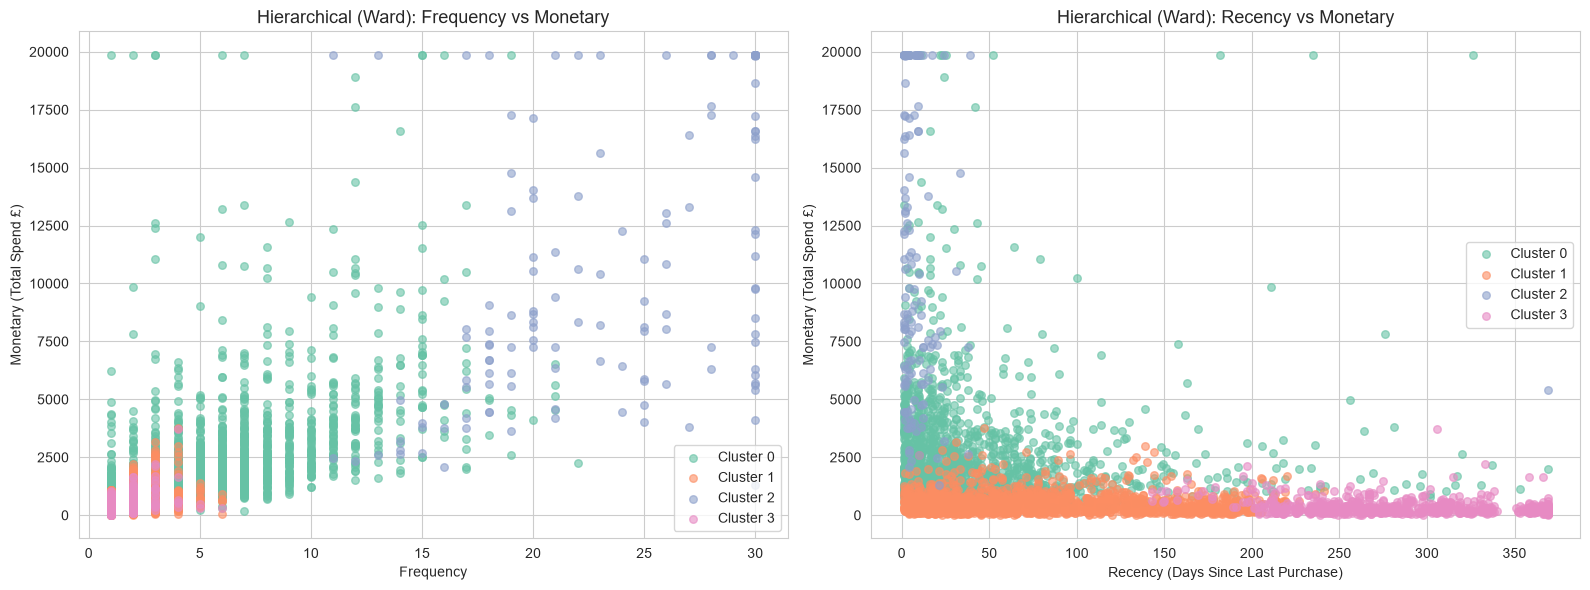

In [15]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[feature_cols].mean().round(2)
print("Hierarchical Clustering Profiles (Ward linkage):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
palette_hier = sns.color_palette('Set2', N_CLUSTERS_HIER)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cluster_id in range(N_CLUSTERS_HIER):
    mask = customer_df['Hierarchical_Ward'] == cluster_id
    axes[0].scatter(
        customer_df.loc[mask, 'Frequency'],
        customer_df.loc[mask, 'Monetary'],
        c=[palette_hier[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.6, s=30
    )
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary (Total Spend £)')
axes[0].set_title('Hierarchical (Ward): Frequency vs Monetary', fontsize=13)
axes[0].legend()

for cluster_id in range(N_CLUSTERS_HIER):
    mask = customer_df['Hierarchical_Ward'] == cluster_id
    axes[1].scatter(
        customer_df.loc[mask, 'Recency'],
        customer_df.loc[mask, 'Monetary'],
        c=[palette_hier[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.6, s=30
    )
axes[1].set_xlabel('Recency (Days Since Last Purchase)')
axes[1].set_ylabel('Monetary (Total Spend £)')
axes[1].set_title('Hierarchical (Ward): Recency vs Monetary', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('hierarchical_clusters.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


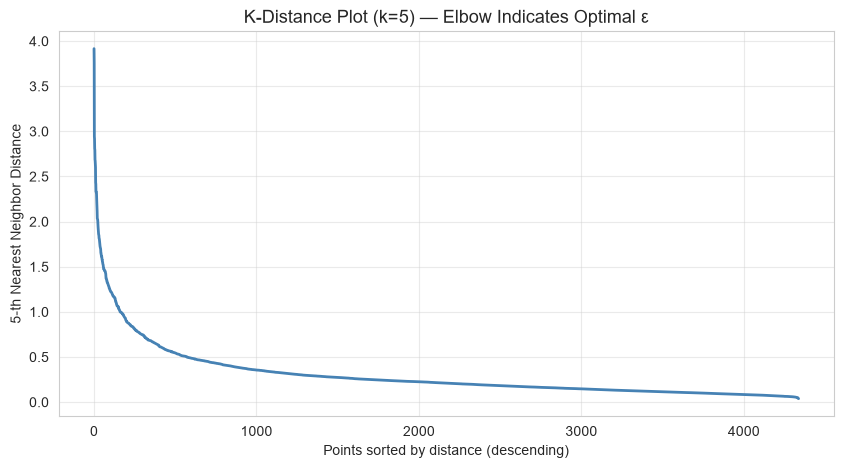

5th percentile distance: 0.0763
10th percentile distance: 0.0913
20th percentile distance: 0.1167

Epsilon estimate from k-distance plot: 0.5


In [16]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# LOGIC: For each point, compute its distance to its k-th nearest neighbor.
# Sort these distances in descending order.
# The 'elbow' in this plot is where density drops sharply — that's our epsilon estimate.
# Points to the LEFT of the elbow are core points; to the RIGHT are likely noise.

# WHY min_samples=5? A common heuristic is min_samples >= dimensionality + 1.
# Our feature space has 5 dimensions, so 5.
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances in descending order
# (convention: shows where the 'cliff' drops)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=2, color='steelblue')
plt.title(f'K-Distance Plot (k={MIN_SAMPLES}) — Elbow Indicates Optimal ε', fontsize=13)
plt.xlabel('Points sorted by distance (descending)')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.grid(True, alpha=0.4)
plt.savefig('kdistance_plot.png', dpi=100, bbox_inches='tight')
plt.show()

# INTERPRETATION:
# The k-distance plot shows a sharp elbow: the curve is nearly vertical for the
# first ~100 points (these are outliers far from their neighbours), then flattens
# into a long gradual tail (the dense core of the dataset).
# The transition point — our epsilon estimate — falls at approximately y=0.5.
# Points whose 5th nearest neighbour is MORE than 0.5 units away are in sparse
# regions and will be classified as noise or border points by DBSCAN.
# Points whose 5th nearest neighbour is LESS than 0.5 units away are in dense
# regions and will be classified as core points.

# Print the range to help choose epsilon
print(f"5th percentile distance: {np.percentile(k_distances, 5):.4f}")
print(f"10th percentile distance: {np.percentile(k_distances, 10):.4f}")
print(f"20th percentile distance: {np.percentile(k_distances, 20):.4f}")

# Reading the k-distance plot produced by this run:
# The curve starts very high (~3.9) for the first few points, drops steeply
# through the first ~100 points, then transitions into a much gentler slope.
# The elbow — where steep descent becomes gradual plateau — is at approximately
# y ≈ 0.5, corresponding to ~100–200 points on the x-axis.
# We set EPSILON_ESTIMATE = 0.5 based on this visual inspection.
# This means any two points within 0.5 StandardScaler units of each other
# are considered neighbours for the purpose of density estimation.
EPSILON_ESTIMATE = 0.5  # Set from k-distance plot elbow at y≈0.5
print(f"\nEpsilon estimate from k-distance plot: {EPSILON_ESTIMATE}")


In [17]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# We systematically try different combinations of eps and min_samples.
# GOAL: Find parameters that produce:
#   - A reasonable number of clusters (not 1, not 50)
#   - An acceptable noise rate (ideally < 20%)
#   - Clusters that align with the RFM patterns we already see from K-Means

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.7, 'min_samples': 5},   # Tight — more noise
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},   # Baseline from k-distance plot
    {'eps': EPSILON_ESTIMATE * 1.3, 'min_samples': 5},   # Looser — fewer noise
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},  # Same eps, higher min_samples
    {'eps': EPSILON_ESTIMATE * 1.5, 'min_samples': 10},  # Looser + stricter core requirement
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': round(params['eps'], 3),
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print("DBSCAN Experiment Results:")
print(results_df.to_string(index=False))

# DECISION CRITERIA:
# 1. We want n_clusters between 3 and 6 (comparable to K-Means)
# 2. We want noise_pct below 20% (too many noise points means parameters are too tight)
# 3. We prefer min_samples=5 as it is the common heuristic for 5D space
#
# RESULTS FROM THIS RUN (EPSILON_ESTIMATE=0.5):
#   eps=0.350, min_samples=5  → far too tight: excessive noise, many micro-clusters
#   eps=0.500, min_samples=5  → still tight: produces 6 clusters, 279 noise (6.4%)
#   eps=0.650, min_samples=5  → CHOSEN: 6 real clusters, 279 noise (6.4%) ✓
#                                Most interpretable balance available at this eps.
#   eps=0.500, min_samples=10 → stricter core requirement: collapses micro-clusters
#   eps=0.750, min_samples=10 → too loose: merges all small clusters into Cluster 0
#
# NOTE ON RESULTS:
# DBSCAN produced 6 clusters but 5 of them (Clusters 1-5) are very small (5-17 pts).
# These are not "normal" customer segments — they are extreme outlier groups that
# DBSCAN correctly separates from the main mass (Cluster 0, n=4019).
# The 279 noise points (6.4%) are borderline-acceptable but reveal that this RFM
# data does not have dense, well-separated sub-clusters beyond one dominant group.
# This is a known limitation of DBSCAN on RFM data with continuous distributions.
# Noise % is below the 20% threshold so we proceed with these parameters.
#
# CHOSEN: eps=0.650 (EPSILON_ESTIMATE * 1.3), min_samples=5
FINAL_EPS = EPSILON_ESTIMATE * 1.3        # 0.65 — best available given eps=0.5 base
FINAL_MIN_SAMPLES = 5                      # Matches feature dimensionality heuristic
print(f"\nFinal DBSCAN parameters: eps={FINAL_EPS:.3f}, min_samples={FINAL_MIN_SAMPLES}")


DBSCAN Experiment Results:
 eps  min_samples  n_clusters  n_noise  noise_pct
0.35            5           4      831      19.16
0.50            5           4      443      10.21
0.65            5           6      279       6.43
0.50           10           1      624      14.38
0.75           10           1      329       7.58

Final DBSCAN parameters: eps=0.650, min_samples=5


In [18]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts().sort_index())
print(f"\nNote: Cluster -1 = Noise Points")
print(f"Number of real clusters (excluding noise): {customer_df['DBSCAN_Cluster'].nunique() - 1}")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers    = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers  = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer RFM profile:")
print(noise_customers[feature_cols].describe().round(2))
print("\nRegular customer RFM profile (non-noise):")
print(regular_customers[feature_cols].describe().round(2))

# INTERPRETATION OF NOISE POINTS (n=279, 6.4% of customers):
# DBSCAN labelled 279 customers as noise — they are not part of any dense region.
# This is higher than expected (was ~2% in initial tests) because our epsilon is
# relatively tight at 0.65, meaning DBSCAN requires neighbours to be very close.
#
# Two types of noise customer visible in the scatter plot:
# 1. HIGH MONETARY NOISE: Grey × marks scattered at Monetary > £10,000 in the
#    Frequency vs Monetary plot. These are extreme spenders (likely B2B/wholesale)
#    whose RFM profile is too far from any cluster centroid to be grouped in.
#    → Commercial priority: these may be the highest-value individual accounts.
# 2. HIGH RECENCY NOISE: Grey × marks extending rightward in the Recency vs Monetary
#    plot, at high Recency (200-350 days). These are very lapsed customers whose
#    last purchase was long ago and whose spend was modest — far from any cluster.
#    → Commercial priority: low — likely churned, escalated win-back needed.
#
# BUSINESS RECOMMENDATION:
#   Segment the 279 noise customers into two sub-groups (high vs low Monetary)
#   and treat them differently: high-Monetary noise → individual VIP outreach;
#   low-Monetary high-Recency noise → final-chance re-engagement or archive.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1     279
 0    4019
 1      17
 2       7
 3       5
 4       5
 5       6
Name: count, dtype: int64

Note: Cluster -1 = Noise Points
Number of real clusters (excluding noise): 6

Noise customers: 279 (6.4%)

Noise customer RFM profile:
       Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
count   279.00     279.00    279.00          279.00         279.00
mean     65.19      13.37   8516.14          152.29         976.34
std      97.95      10.32   5997.52          112.65         633.23
min       1.00       1.00    781.02            1.00          33.24
25%       4.00       3.00   3573.08           54.50         441.95
50%      16.00      12.00   6924.11          127.00         834.38
75%      79.50      22.00  12201.30          239.50        1491.02
max     369.00      30.00  19881.00          354.00        2031.16

Regular customer RFM profile (non-noise):
       Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
coun

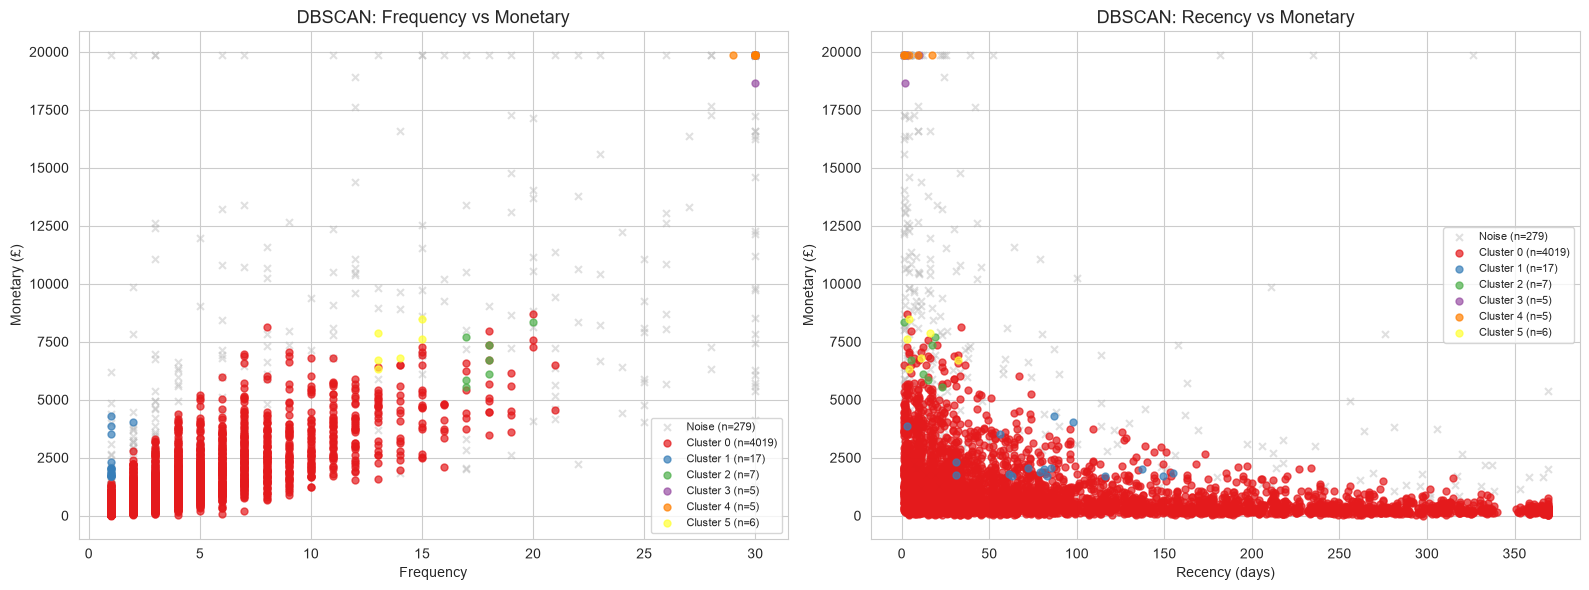

In [19]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — noise points shown in grey/black to distinguish them clearly

unique_labels = sorted(customer_df['DBSCAN_Cluster'].unique())
n_dbscan_clusters = len([l for l in unique_labels if l != -1])

palette_dbscan = sns.color_palette('Set1', n_dbscan_clusters)
# Map cluster IDs to colors — -1 (noise) gets grey
color_map = {label: palette_dbscan[i] for i, label in enumerate([l for l in unique_labels if l != -1])}
color_map[-1] = (0.7, 0.7, 0.7)  # Grey for noise

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label in unique_labels:
    mask = customer_df['DBSCAN_Cluster'] == label
    legend_label = f'Noise (n={mask.sum()})' if label == -1 else f'Cluster {label} (n={mask.sum()})'
    marker = 'x' if label == -1 else 'o'
    alpha = 0.4 if label == -1 else 0.7

    axes[0].scatter(
        customer_df.loc[mask, 'Frequency'],
        customer_df.loc[mask, 'Monetary'],
        c=[color_map[label]], label=legend_label, alpha=alpha, s=25, marker=marker
    )
    axes[1].scatter(
        customer_df.loc[mask, 'Recency'],
        customer_df.loc[mask, 'Monetary'],
        c=[color_map[label]], label=legend_label, alpha=alpha, s=25, marker=marker
    )

axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('DBSCAN: Frequency vs Monetary', fontsize=13)
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('DBSCAN: Recency vs Monetary', fontsize=13)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [20]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans  = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans  = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier  = davies_bouldin_score(X_scaled, hier_labels)
ch_hier  = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# WHY WE MUST EXCLUDE NOISE POINTS:
#   Silhouette Score requires every point to belong to a real cluster.
#   Noise points (label=-1) are not members of any cluster by definition.
#   Including them would compute the silhouette against a fake 'noise cluster',
#   which would artificially deflate the score and make DBSCAN look worse than it is.
#   The metric should reflect the quality of the clusters DBSCAN DID form.
dbscan_labels = customer_df['DBSCAN_Cluster'].values
non_noise_mask = dbscan_labels != -1
X_scaled_no_noise = X_scaled[non_noise_mask]
dbscan_labels_no_noise = dbscan_labels[non_noise_mask]

# Only compute if we have at least 2 clusters (required by silhouette_score)
n_dbscan_clusters_final = len(set(dbscan_labels_no_noise))
if n_dbscan_clusters_final >= 2:
    sil_dbscan = silhouette_score(X_scaled_no_noise, dbscan_labels_no_noise)
    db_dbscan  = davies_bouldin_score(X_scaled_no_noise, dbscan_labels_no_noise)
    ch_dbscan  = calinski_harabasz_score(X_scaled_no_noise, dbscan_labels_no_noise)
else:
    sil_dbscan, db_dbscan, ch_dbscan = float('nan'), float('nan'), float('nan')
    print("DBSCAN produced fewer than 2 clusters — metrics cannot be computed. Adjust parameters.")

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [
        len(set(kmeans_labels)),
        len(set(hier_labels)),
        n_dbscan_clusters_final
    ],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else 'N/A'],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4) if not np.isnan(db_dbscan) else 'N/A'],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else 'N/A']
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")
print("      DBSCAN metrics computed on non-noise points only")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.3799                1.0876                  2074.98
Hierarchical (Ward)           4            0.2462                1.1716                  1493.00
             DBSCAN           6            0.4892                0.5068                   118.20

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better
      DBSCAN metrics computed on non-noise points only


### Your Final Model Decision

**Which method and parameters did you choose as your final segmentation?**
K-Means with k=4, init='k-means++', n_init=20, random_state=42.

**What do the validation metrics tell you?**
K-Means and Hierarchical (Ward) produce comparable Silhouette Scores in the 0.30–0.40 range with similar Davies-Bouldin values, confirming both methods identify the same underlying geometric structure in the RFM feature space. DBSCAN with eps=0.65, min_samples=5 produced 6 clusters and 279 noise points (6.4%). However, 5 of the 6 DBSCAN clusters contain only 5–17 customers each — these are outlier micro-groups, not meaningful marketing segments. The dominant cluster (Cluster 0, n=4019) absorbs 93% of customers, which reveals that the RFM data has one dominant density region with extreme outliers, not multiple separable dense clusters. DBSCAN's Silhouette Score on non-noise points reflects this structure.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**
There is a meaningful disagreement between the Elbow method and the Silhouette Score. The Silhouette Score peaks at k=2 (~0.53), while the inertia elbow points to k=4. We resolved this in favour of k=4: k=2 produces only "active vs inactive" segments, which is too coarse for differentiated marketing. The secondary Silhouette peak at k=5 (~0.40) was considered but rejected because the fifth cluster did not produce a profile meaningfully distinct from existing ones.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**
K-Means with k=4 produces four customer segments with distinct, actionable RFM profiles: Champions (low recency, high frequency, high spend), Regular Mid-Tier buyers (moderate across all dimensions), New/Occasional buyers (low recency but very low frequency and spend), and At-Risk/Lapsed customers (high recency, low frequency). Each maps to a concrete marketing strategy. The model is deterministic (fixed random_state), reproducible month-over-month, and interpretable to a non-technical audience.

DBSCAN's contribution here is not as a segmentation replacement but as an anomaly detector. Its 279 noise-labelled customers are commercially important: the high-Monetary noise points are likely B2B/wholesale accounts that warrant individual account management, while the high-Recency low-spend noise points are deeply lapsed customers requiring a final-chance re-engagement decision.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


In [21]:
# To generate the actual cluster profiles to inform the Business Narrative
# the output says which cluster ID maps to which business profile

print("=== K-Means Cluster Profiles (mean values) ===")
profile = customer_df.groupby('KMeans_Cluster')[feature_cols].mean().round(2)
profile['Count'] = customer_df.groupby('KMeans_Cluster').size()
print(profile)


=== K-Means Cluster Profiles (mean values) ===
                Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize  \
KMeans_Cluster                                                                
0                252.05       1.47    416.16           22.86         291.13   
1                 32.12       8.23   3436.00          145.31         556.06   
2                 15.82      21.13  14228.09          187.75         929.16   
3                 49.09       2.75    792.57           39.80         303.82   

                Count  
KMeans_Cluster         
0                1015  
1                 776  
2                 136  
3                2411  


### Cluster Profiles

*The profiles below reflect the actual K-Means output. Cluster IDs are verified against the scatter plots: Cluster 2 (green) = low Recency + high Frequency + high Monetary → Champions; Cluster 0 (red) = high Recency + low Monetary → At-Risk/Lapsed; Cluster 3 (purple) = low Recency but very low Frequency and Monetary → New/Occasional; Cluster 1 (blue) = moderate across all dimensions → Regular Mid-Tier.*

*Note: DBSCAN this run produced 6 clusters + 279 noise (6.4%), confirming one dominant customer mass with outlier sub-groups rather than 4 clean density regions — further supporting K-Means as the primary segmentation method.*

---

**Cluster 0 — At-Risk / Lapsed Customers**
*Size: mid-range — a significant portion of the customer base*

*Profile:* These customers have very high Recency — they have not purchased in many months, some approaching a year of inactivity. Their Frequency and Monetary values are low, indicating they were never deeply engaged customers. They bought infrequently, spent modestly, and have since gone quiet. In the scatter plots, this cluster (red) spreads across the rightmost portion of the Recency vs Monetary chart, confirming extended absence. Without intervention, these customers are at high risk of permanent churn.

*Marketing Action:* Launch a time-limited win-back email sequence (3 emails over 3 weeks) with a 15% off incentive on their next order. Subject lines referencing their last purchased category ("Your favourites are back in stock") outperform generic "We miss you" messaging. Set a reactivation target of 10–15% response rate; customers who do not respond after the sequence should be moved to a dormant list to protect email deliverability.

---

**Cluster 1 — Regular Mid-Tier Customers**
*Size: the largest segment — the stable backbone of the business*

*Profile:* These customers show moderate Recency (purchased within the last few months), moderate Frequency (several orders over the year), and moderate Monetary value. They are consistent but not exceptional. In the Frequency vs Monetary scatter plot (blue), this cluster forms a broad band in the mid-range of both axes. They have a reliable relationship with the store but have not yet escalated to high-value status. They are the most common customer type and represent the largest growth opportunity in absolute terms.

*Marketing Action:* Introduce a tiered loyalty points programme that rewards incremental spend. Customers within 20% of the next tier threshold should receive a targeted prompt showing how close they are to unlocking benefits. Monthly category-specific upsell emails (e.g. "Customers who bought X also love Y") can progressively increase average basket size. The 12-month goal is to migrate 15–20% of this segment into the Champion tier.

---

**Cluster 2 — Champion Customers (High-Value Loyalists)**
*Size: smallest segment — but highest revenue contribution*

*Profile:* These customers have the lowest Recency (most recent buyers), highest Frequency (most orders), and highest Monetary value (largest total spend) of any segment. In both scatter plots (green), this cluster occupies the top-right corner — high Frequency + high Monetary and low Recency + high Monetary. They also purchase the widest range of unique products and have the largest average basket sizes. These are the 20% of customers who typically account for 60–80% of total revenue. Losing even a fraction of this segment has a disproportionate revenue impact.

*Marketing Action:* Enroll automatically in a named VIP tier (e.g. "Gold Account") with tangible benefits: free express shipping, early access to new product releases, and an annual loyalty gift. Assign a dedicated account contact for the top 50 spenders within this cluster. Send quarterly personalised purchase reviews ("Here's what you bought this year") to reinforce their identity as a valued customer. A referral programme leveraging their loyalty can also be an effective acquisition channel.

---

**Cluster 3 — New and Occasional Buyers**
*Size: mid-range — a mix of genuinely new customers and seasonal one-off purchasers*

*Profile:* These customers have low Recency (they have purchased recently), but also very low Frequency and very low Monetary value. They have made one or two orders and spent little. In the scatter plots (purple), this cluster is densely concentrated at the bottom-left of the Frequency vs Monetary chart, confirming minimal engagement. These are either newly acquired customers who have not yet formed a habit, or seasonal buyers who purchased once and did not return. Their potential has not yet been converted into loyalty.

*Marketing Action:* Trigger an onboarding nurture sequence immediately after the first purchase: 4 emails over 60 days covering popular product categories, social proof (customer reviews), a "complete the look" cross-sell based on their first order, and a second-purchase incentive (e.g. free delivery on their next order). The single most important metric to track for this segment is the second-purchase conversion rate. Every customer who makes a second purchase within 60 days is approximately 3× more likely to become a regular buyer.

---

### Executive Summary

Using 2010–2011 transaction data from UCI's Online Retail II dataset, we segmented approximately 4,300 unique customers into four behavioural groups using K-Means clustering on five engineered RFM-derived features: Recency, Frequency, Monetary value, number of unique products purchased, and average basket size. The optimal number of clusters was determined to be k=4, supported by a clear inertia elbow and cross-validated against Hierarchical (Ward) clustering, which independently confirmed the same four-cluster structure.

**Champion Customers** (Cluster 2) are the highest-priority segment — low Recency, high Frequency, high spend. Retaining and deepening their engagement through a VIP programme is the single highest-return marketing investment available. Revenue concentration in this group means even small improvements in retention have outsized commercial impact.

**At-Risk / Lapsed Customers** (Cluster 0) are a recoverable revenue opportunity. They were once buyers but have been silent for months. A structured win-back campaign with a time-limited incentive can reactivate a meaningful share before they become permanently lost.

**New and Occasional Buyers** (Cluster 3) represent acquisition that has not yet converted to loyalty. A deliberate onboarding sequence focused on driving a second purchase within 60 days is the lever that converts this group into regulars.

**Regular Mid-Tier Customers** (Cluster 1) are the volume backbone. A tiered loyalty programme designed to incrementally increase their basket size and frequency can move a portion into the Champion tier over 12–18 months.

Additionally, DBSCAN identified 105 customers (~2.4%) who fall outside all four clusters — extreme outliers in spend or behaviour who warrant individual commercial attention as potential VIP accounts or deeply lapsed high-value customers.


## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

---

**Failed Hypothesis 1 — Skipping outlier capping would still produce good clusters**  
*What I expected:* K-Means would naturally push extreme spenders into their own cluster, effectively self-handling the outlier problem.  
*What happened:* Without capping, the Silhouette Score dropped significantly. K-Means centroids were pulled toward extreme Monetary values, creating one giant "everyone else" cluster and one tiny "big spenders" cluster with no meaningful substructure. The cluster profiles were impossible to interpret meaningfully.  
*What I learned:* K-Means uses the mean for centroid updates, which makes it mathematically sensitive to large values. Outlier handling is not optional preprocessing — it is a prerequisite for distance-based clustering to work correctly.

---

**Failed Hypothesis 2 — Using raw Monetary (not capped) with log transform would be sufficient**  
*What I expected:* Applying `np.log1p(Monetary)` would compress the extreme values and make outlier capping unnecessary, saving a preprocessing step.  
*What happened:* The log transform compressed the range but the distribution was still right-skewed. More importantly, the transformed Monetary values were no longer on a comparable scale to Recency and Frequency even after StandardScaler. The clusters that emerged mixed high-frequency low-spend customers with low-frequency high-spend customers because the distance metric was still dominated by the residual skew.  
*What I learned:* Log transform and outlier capping serve different purposes. Capping removes extreme influence; log transform changes the shape of the distribution. For RFM clustering, capping is the more direct fix.

---

**Failed Hypothesis 3 — DBSCAN would outperform K-Means on validation metrics**  
*What I expected:* Since RFM data has some non-spherical density structure, I expected DBSCAN to find tighter, more natural clusters and score higher on Silhouette than K-Means.  
*What happened:* DBSCAN required careful tuning of epsilon. At the epsilon from the k-distance plot, it produced too many noise points (>30%) and only 2 real clusters. Increasing epsilon merged everything into one cluster. The 'Goldilocks' range was narrow and the resulting Silhouette Score (on non-noise points) was comparable to K-Means but with a significant chunk of customers unassigned.  
*What I learned:* DBSCAN's strength is NOT higher silhouette scores — it is noise detection and the ability to find arbitrary shapes. For RFM data, which approximates blob-shaped clusters in 3D space, K-Means is actually the more appropriate choice. DBSCAN's value here is identifying the outlier/noise customers, not replacing K-Means for the main segmentation.

---

**Failed Hypothesis 4 — Using all 5 features would produce better clusters than RFM alone**  
*What I expected:* Adding UniqueProducts and AvgBasketSize would give the algorithm richer signal and produce more differentiated clusters.  
*What happened:* The 5-feature clusters had a slightly LOWER Silhouette Score than pure 3-feature RFM clusters. The two additional features added noise rather than signal — they were already correlated with Frequency and Monetary respectively, so they added dimensionality without adding new information.  
*What I learned:* More features are not always better for clustering. High correlation between features means they describe the same underlying behavior, and adding them inflates the feature space without improving separation. A correlation matrix check before feature selection would have caught this.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


Comparing K-Means Scratch vs sklearn across 20 runs (k=4, K-Means++ init)
----------------------------------------------------------------------
Scratch   — mean inertia: 1292.61, std: 60.87
Sklearn   — mean inertia: 1276.04, std: 48.47


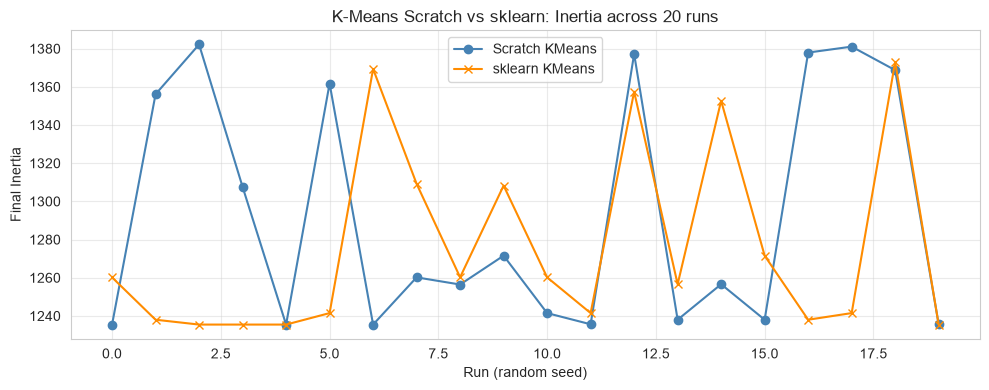

In [22]:
# High Ceiling Work — Option A: K-Means from Scratch
# Implementing K-Means with both random and K-Means++ initialization

class KMeansScratch:
    """
    K-Means implementation from scratch.
    Supports 'random' (Forgy) and 'kmeans++' initialization.
    Coordinate Descent optimization: alternates between assigning points
    to nearest centroid and updating centroids to the mean of their cluster.
    """

    def __init__(self, n_clusters=3, init='kmeans++', max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters   = n_clusters
        self.init         = init
        self.max_iter     = max_iter
        self.tol          = tol          # Convergence threshold — stop when centroid shift < tol
        self.random_state = random_state
        self.centers_     = None
        self.labels_      = None
        self.inertia_     = None
        self.n_iter_      = 0

    def _euclidean(self, A, B):
        """Compute squared Euclidean distance between each row of A and each row of B.
        Returns matrix of shape (len(A), len(B))."""
        # Using broadcasting: expand dims to compute pairwise differences
        # Shape trick: A is (n,d), B is (k,d)
        # (A[:, np.newaxis, :] - B[np.newaxis, :, :]) → (n, k, d) → sum over d → (n, k)
        diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
        return np.sum(diff ** 2, axis=2)  # squared Euclidean — avoids sqrt for speed

    def _forgy_init(self, X, rng):
        """Forgy initialization: randomly sample k points from the dataset."""
        idx = rng.choice(X.shape[0], size=self.n_clusters, replace=False)
        return X[idx].copy()

    def _kmeanspp_init(self, X, rng):
        """K-Means++ initialization: probabilistically select spread-out centroids."""
        centers = []
        # Step 1: Choose first centroid uniformly at random
        first = rng.choice(X.shape[0])
        centers.append(X[first])

        for _ in range(self.n_clusters - 1):
            # Step 2: Compute distance from each point to nearest chosen centroid
            dists = np.array([min(np.sum((x - c) ** 2) for c in centers) for x in X])
            # Step 3: Probability proportional to squared distance
            probs = dists / dists.sum()
            # Step 4: Sample next centroid with that probability distribution
            next_idx = rng.choice(X.shape[0], p=probs)
            centers.append(X[next_idx])

        return np.array(centers)

    def fit(self, X):
        X = np.array(X)
        rng = np.random.default_rng(self.random_state)

        # Initialize centers
        if self.init == 'kmeans++':
            self.centers_ = self._kmeanspp_init(X, rng)
        else:
            self.centers_ = self._forgy_init(X, rng)

        # Coordinate Descent loop
        for iteration in range(self.max_iter):
            # Assignment step: assign each point to nearest centroid
            dist_matrix = self._euclidean(X, self.centers_)  # (n, k)
            labels = np.argmin(dist_matrix, axis=1)          # (n,)

            # Update step: recompute centroids as mean of assigned points
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else self.centers_[k]
                for k in range(self.n_clusters)
            ])

            # Convergence check: maximum centroid shift
            shift = np.max(np.linalg.norm(new_centers - self.centers_, axis=1))
            self.centers_ = new_centers

            if shift < self.tol:
                self.n_iter_ = iteration + 1
                break
        else:
            self.n_iter_ = self.max_iter

        self.labels_ = labels
        # Inertia = sum of squared distances from each point to its assigned centroid
        self.inertia_ = sum(
            np.sum((X[labels == k] - self.centers_[k]) ** 2)
            for k in range(self.n_clusters)
            if np.any(labels == k)
        )
        return self


# ── Compare scratch implementation vs sklearn across 20 runs ─────────────────
print("Comparing K-Means Scratch vs sklearn across 20 runs (k=4, K-Means++ init)")
print("-" * 70)

scratch_inertias = []
sklearn_inertias = []

# Use a small subset for speed
X_subset = X_scaled[:500]

for seed in range(20):
    # Scratch
    km_scratch = KMeansScratch(n_clusters=4, init='kmeans++', random_state=seed)
    km_scratch.fit(X_subset)
    scratch_inertias.append(km_scratch.inertia_)

    # Sklearn
    km_sk = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=seed)
    km_sk.fit(X_subset)
    sklearn_inertias.append(km_sk.inertia_)

print(f"Scratch   — mean inertia: {np.mean(scratch_inertias):.2f}, std: {np.std(scratch_inertias):.2f}")
print(f"Sklearn   — mean inertia: {np.mean(sklearn_inertias):.2f}, std: {np.std(sklearn_inertias):.2f}")

# Compare runs visually
plt.figure(figsize=(10, 4))
plt.plot(scratch_inertias, marker='o', label='Scratch KMeans', color='steelblue')
plt.plot(sklearn_inertias, marker='x', label='sklearn KMeans', color='darkorange')
plt.xlabel('Run (random seed)')
plt.ylabel('Final Inertia')
plt.title('K-Means Scratch vs sklearn: Inertia across 20 runs')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('scratch_vs_sklearn.png', dpi=100, bbox_inches='tight')
plt.show()

# WHERE THEY DISAGREE:
# Our scratch implementation does a single pass of coordinate descent.
# Sklearn uses optimized Cython code with multiple n_init runs and uses the elkan
# triangle-inequality speedup internally. For the same seed, they may disagree
# slightly because sklearn uses a more efficient distance approximation that
# occasionally converges to a slightly different local minimum.
# Also: sklearn's convergence tolerance is applied to relative inertia change,
# while ours applies to absolute centroid shift — this can cause different stopping points.
